In [1]:
import pandas 

ex = pandas.read_excel("mpc.xlsx")

In [2]:
import numpy,math

xbar = numpy.mean(ex['MPC'])
print("la moyenne de moyenne pondérée cumulative -MPC- est:"+str(round(xbar,2)))

la moyenne de moyenne pondérée cumulative -MPC- est:3.46


In [3]:
ecarte_type = numpy.std(ex['MPC'], ddof=1)
print("l'ecarte type de MPC -> moyenne pondérée cumulative est :"+str(round(ecarte_type,2)))

l'ecarte type de MPC -> moyenne pondérée cumulative est :0.44


In [4]:
variance = numpy.var(ex['MPC'], ddof=1)
print("la variance de MPC -> moyenne pondérée cumulative est:"+str(round(variance,2)))

la variance de MPC -> moyenne pondérée cumulative est:0.2


In [5]:
variance_biaisee = numpy.var(ex['MPC'])
print("la variance biaisee de MPC -> moyenne pondérée cumulative est:"+str(round(variance_biaisee,2)))

la variance biaisee de MPC -> moyenne pondérée cumulative est:0.19


Text(0.5, 1.0, 'histogramme :')

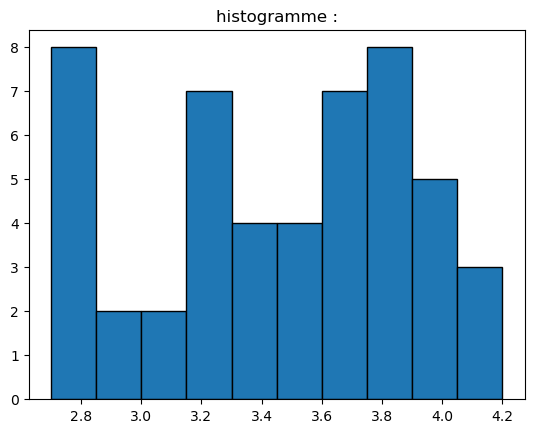

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline 
plt.hist(ex['MPC'], bins=10, edgecolor='black')
plt.title("histogramme :")

In [7]:
import scipy 
from scipy.stats import t
alpha = 0.05
n_ex = len(ex)
icinf = xbar-scipy.stats.t.ppf(1-alpha/2,n_ex-1)*ecarte_type/math.sqrt(n_ex-1)
round(icinf,2)
icsup = xbar+scipy.stats.t.ppf(1-alpha/2,n_ex-1)*ecarte_type/math.sqrt(n_ex-1)
round(icsup,2)
print('Intervalle de confiance IC sur moyenne du ecart type inconnu est : '+'['+str(round(icinf,2))+', '+str(round(icsup,2))+']')

Intervalle de confiance IC sur moyenne du ecart type inconnu est : [3.34, 3.59]


In [8]:
from scipy.stats import norm
ecarte_type2=2
icinf=xbar-scipy.stats.norm.ppf(1-alpha/2)*ecarte_type2/math.sqrt(n_ex)
round(icinf,2)
icsup=xbar+scipy.stats.norm.ppf(1-alpha/2)*ecarte_type2/math.sqrt(n_ex)
round(icsup,2)
print('Intervalle de confiance IC sur moyenne du ecart type connu est   : '+'['+str(round(icinf,2))+' , '+str(round(icsup,2))+']')


Intervalle de confiance IC sur moyenne du ecart type connu est   : [2.91 , 4.02]


In [11]:
scipy.stats.ttest_1samp(ex['MPC'],50)

TtestResult(statistic=-741.2956571469958, pvalue=6.822112567585388e-101, df=49)

l hypotése nulle  est : H0 : m0=50
l hypotése alternatif :H1 : m>50
Statistique test :
TtestResult(statistic=-741.2956571469958, pvalue=6.822112567585388e-101, df=49)


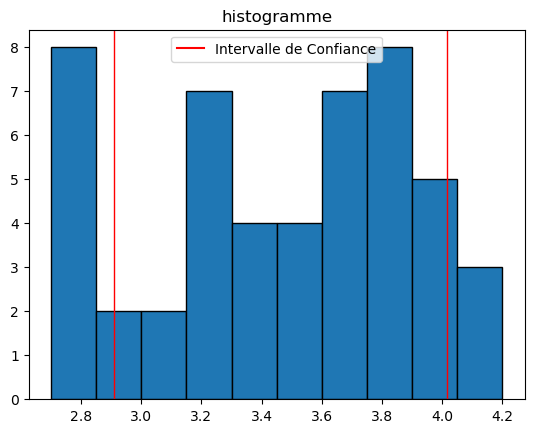

In [13]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
plt.hist(ex['MPC'], bins=10, edgecolor='black')
plt.title("histogramme")
plt.axvline(icinf, color='red', linewidth=1)
plt.axvline(icsup, color='red', linewidth=1)
plt.legend(handles=[mlines.Line2D([], [], color='red',markersize=6, label="Intervalle de Confiance")])
print('l hypotése nulle  est : H0 : m0=50')
print('l hypotése alternatif :H1 : m>50')
print('Statistique test :')
print(scipy.stats.ttest_1samp(ex['MPC'],50))